In [1]:
from trainModel import trainModel
from Dataset import ModelDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, confusion_matrix, accuracy_score, precision_recall_curve
import pandas as pd
import os
from generateSplits import generateSplits
from torch.utils.data import DataLoader
import torch,gc
import numpy as np
from typing import Literal, Callable, Iterator
from functools import partial
import matplotlib.pyplot as plt

In [ ]:
best_params = {'lr': 0.010203264127576701, 'weight_decay': 0.004617603477095672, 'batch_size': 8, 'optimiser_name': 'Adam'}

In [3]:
DATASET_PATH = r"E:\SRP\SRP-2025-Project\ISPY2_T0_T3_DCE_npz"
MODEL_SAVE_PATH = r"E:\SRP\SRP-2025-Project\model_weights"

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
dataset_df = pd.read_excel(r"e:\SRP\ISPY2-Data-Collector\ISPY2-Imaging-Cohort-1-Clinical-Data.xlsx")
dataset_df = dataset_df.set_index("Patient_ID",drop=True)
dataset_df = dataset_df.loc[dataset_df.index.isin([int(os.path.splitext(fname)[0].replace("ISPY2-","")) for fname in os.listdir(DATASET_PATH)]),["HR","HER2","pCR"]]

train_df, test_df = generateSplits(dataset_df,0.2,seed=2008)
skf = StratifiedKFold(n_splits=4,shuffle=True,random_state=2008)

# Optional: Delete if too slow
train_dataset = ModelDataset(train_df,DATASET_PATH,{0:1,1:2},loading_bar=True)
train_loader = DataLoader(train_dataset,batch_size=best_params["batch_size"],shuffle=True)
test_dataset = ModelDataset(test_df, DATASET_PATH, {0:1,1:1}, loading_bar=True)
test_loader =DataLoader(test_dataset, batch_size=best_params["batch_size"])



100%|██████████████████████████████████████████████████████████████████████████████████████| 342/342 [03:42<00:00,  1.54it/s]


Dataset initialised with 463 entries.


100%|████████████████████████████████████████████████████████████████████████████████████████| 86/86 [01:09<00:00,  1.24it/s]


Dataset initialised with 86 entries.


In [5]:
def get_scores(model:torch.nn.Module,test_loader:DataLoader,combine_timepoints:bool,out_features:Literal[1,2],mode:Literal["preNac","both"]="preNac"):
    model.eval()
    y_true=[]
    y_score=[]
    
    with torch.no_grad():
        for T0_volumes,T3_volumes,mols,labels in test_loader:
            T0_volumes = T0_volumes.to(device)
            T3_volumes = T3_volumes.to(device)
            mols = mols.to(device)
            labels = labels.to(device)
            if combine_timepoints:
                logits = model(torch.cat((T0_volumes,T3_volumes),dim=1),mols,mode)
            else:
                logits = model(T0_volumes,T3_volumes,mols,mode)
                
            if out_features == 1:
                score = torch.sigmoid(logits).squeeze()
            elif out_features == 2:
                score = torch.nn.functional.softmax(logits,dim=1)[:,1]
            y_true.extend(labels.cpu().numpy())
            y_score.extend(score.cpu().numpy())
    return y_true,y_score

def score_to_pred(y_true,y_score):
    fpr,tpr,thresholds = roc_curve(y_true,y_score)
    youden_index = tpr-fpr
    best_idx = np.argmax(youden_index)
    best_threshold = thresholds[best_idx]
    y_pred = np.array(y_score)>=best_threshold
    return y_pred

In [6]:
def evaluate_roc_auc(model:torch.nn.Module,test_loader:DataLoader,combine_timepoints:bool,out_features:Literal[1,2],testKwargs:dict):
    model.eval()
    y_true=[]
    y_score=[]
    
    with torch.no_grad():
        for T0_volumes,T3_volumes,mols,labels in test_loader:
            T0_volumes = T0_volumes.to(device)
            T3_volumes = T3_volumes.to(device)
            mols = mols.to(device)
            labels = labels.to(device)
            if combine_timepoints:
                logits = model(torch.cat((T0_volumes,T3_volumes),dim=1),mols,**testKwargs)
            else:
                logits = model(T0_volumes,T3_volumes,mols,**testKwargs)
                
            if out_features == 1:
                score = torch.sigmoid(logits).squeeze()
            elif out_features == 2:
                score = torch.nn.functional.softmax(logits,dim=1)[:,1]
            y_true.extend(labels.cpu().numpy())
            y_score.extend(score.cpu().numpy())
    return float(roc_auc_score(y_true,y_score))

In [8]:
def getTrainedModel(
    model: torch.nn.Module,
    combine_timepoints: bool,
    out_features: Literal[1, 2],
    loss_fn: Callable,
    trainKwargs: dict,
    testKwargs: dict,
    save:bool,
    filename:str,
):
    optimiser_class = partial(
        torch.optim.AdamW,
        lr=best_params["lr"],
        weight_decay=best_params["weight_decay"],
    )

    trainedModel, _ = trainModel(
        model=model,
        train_loader=train_loader,
        combine_timepoints=combine_timepoints,
        out_features=out_features,
        loss_fn=loss_fn,
        optimiser=optimiser_class(model.parameters()),
        num_epochs=30,
        val_loader=test_loader,
        score_fn=evaluate_roc_auc,
        score_name="ROC AUC",
        patience=10,
        trainKwargs=trainKwargs,
        testKwargs=testKwargs,
    )
    
    if save:
        torch.save(trainedModel.state_dict(), os.path.join(MODEL_SAVE_PATH, filename))
    
    return trainedModel



In [15]:

def plot(y_true,y_score):
    positive_ratio = sum(y_true)/len(y_true)
    
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)  
    
    # ---- Compute Youden Index ----
    youden = tpr - fpr                      # same as sensitivity + specificity - 1
    best_idx = np.argmax(youden)            # index of best threshold
    best_fpr = fpr[best_idx]
    best_tpr = tpr[best_idx]
    youden_index = roc_thresholds[best_idx]
    
    
    
    plt.figure()
    plt.plot(fpr,tpr)
    plt.plot([0, 1], [0, 1], "--")
    # ---- Mark Youden point ----
    plt.scatter(best_fpr, best_tpr, color="red", s=50, zorder=3,
                label=f"Youden Index\nTPR={best_tpr:.3f}, FPR={best_fpr:.3f}")
    
     # ---- Set ticks at 0.1 increments ----
    plt.xticks(np.arange(0.0, 1.1, 0.1))
    plt.yticks(np.arange(0.0, 1.1, 0.1))
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve\nAUC = {roc_auc_score(y_true,y_score):.3f}")
    plt.grid()
    plt.legend()
    

    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
    plt.figure()
    plt.plot(recall,precision)
    plt.axhline(positive_ratio, color="gray", linestyle="--", label=f"Baseline AP = {positive_ratio:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve\nAverage Precision = {average_precision_score(y_true,y_score):.3f}")
    
    y_pred = score_to_pred(y_true,y_score)
    y_signed = np.array([score-youden_index for score in y_score])
    print(sum(y_signed<0))
    # Sort for better visualization
    idx = np.argsort(y_signed)
    y_sorted = np.array(y_signed)[idx]
    labels_sorted = np.array(y_true)[idx]
    # Color by true label: blue = pCR, red = non-pCR
    colors = ["blue" if t==1 else "red" for t in labels_sorted]
    # Plot
    plt.figure(figsize=(24,5))
    plt.bar(range(len(y_sorted)), y_sorted, color=colors, width=0.8)
    plt.ylabel("Predicted Score (positive = pCR, negative = non-pCR)")
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    plt.ylim((1.2*min(y_signed), 1.2*max(y_signed)))
    plt.grid(False)
    plt.title("Predicted scores of participants in the validation set\nBlue = true pCR, Red = true non-pCR\nBars above 0 = predicted pCR, Bars below 0 = predicted non-pCR")

    
    

100%|████████████████████████████████████████████████████████████████████████████████████████| 86/86 [00:25<00:00,  3.34it/s]


Dataset initialised with 86 entries.


100%|████████████████████████████████████████████████████████████████████████████████████████| 86/86 [00:25<00:00,  3.32it/s]


Dataset initialised with 86 entries.


100%|████████████████████████████████████████████████████████████████████████████████████████| 85/85 [00:28<00:00,  3.00it/s]


Dataset initialised with 85 entries.


100%|████████████████████████████████████████████████████████████████████████████████████████| 85/85 [00:24<00:00,  3.52it/s]


Dataset initialised with 85 entries.
117


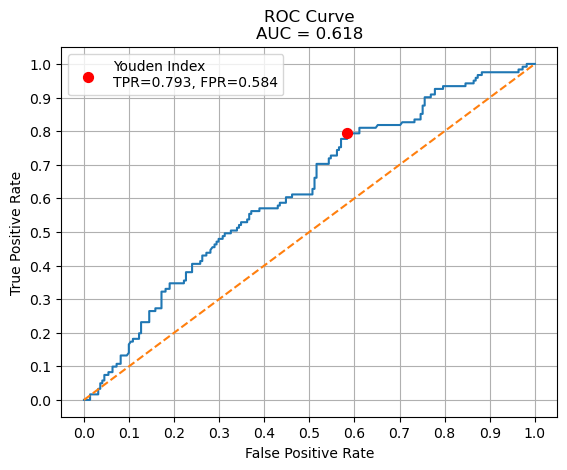

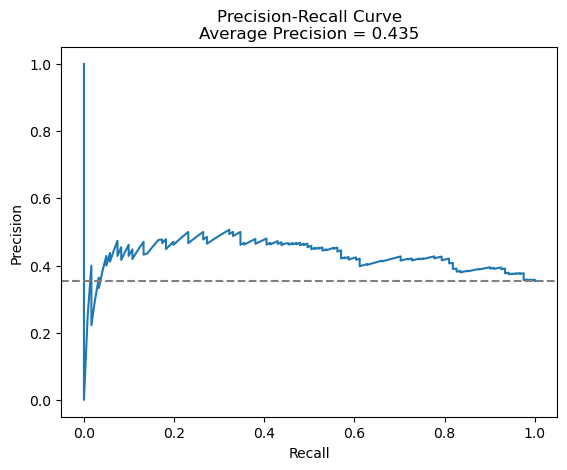

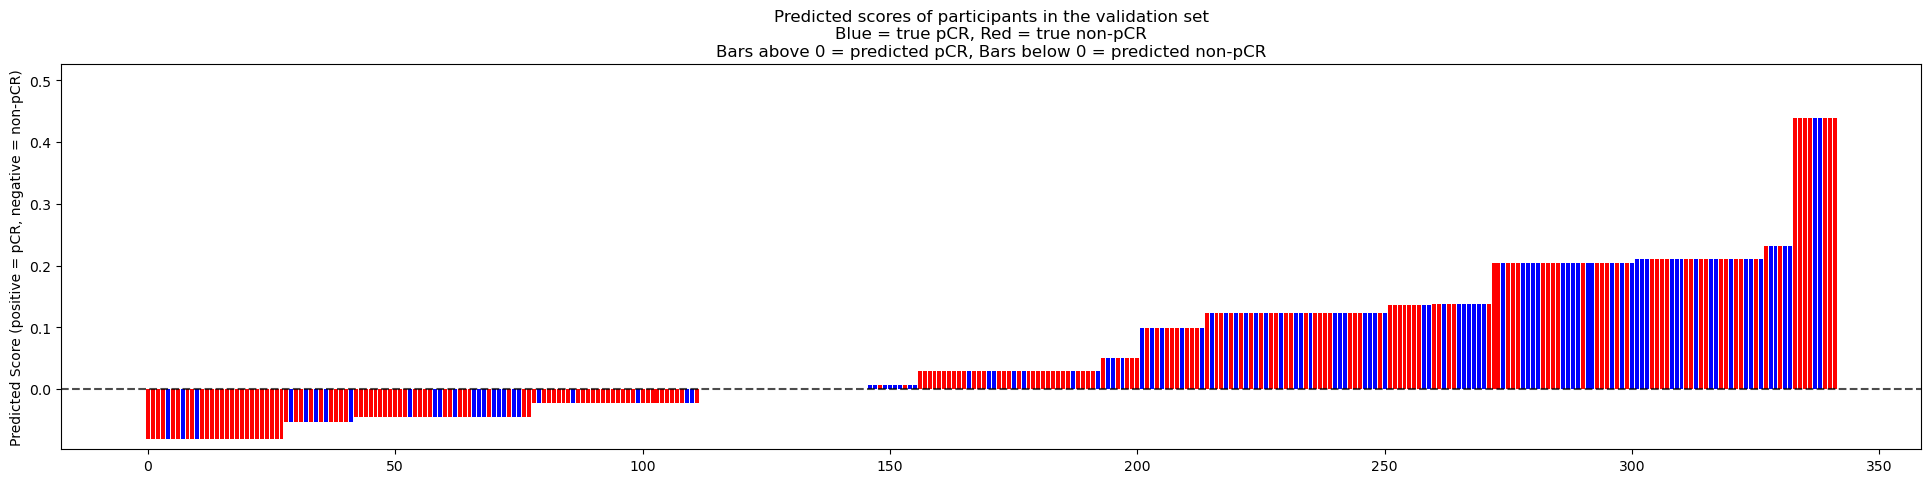

In [16]:
from models.MaxViTwithCAFusion import Model as MaxViTwithCAF

model = MaxViTwithCAF(
    partition_size=(1, 4, 4),
    downsample_depth_schedule=[True, True, False, False],
    fusion_feedforward_dim=256,
    mols_dim=32,
    hidden_fusion_dim=64,
).to(device)

'''
trainedModel = getTrainedModel(
    model,
    combine_timepoints=False,
    out_features=1,
    loss_fn=torch.nn.BCEWithLogitsLoss(),
    trainKwargs={"mode": "both"},
    testKwargs={"mode": "preNac"},
    save = True,
    filename = "MaxViTwithCAF_weights.pt"
)'''

all_y_true = []
all_y_score = []
for i, (train_index,val_index) in enumerate(skf.split(train_df,train_df["pCR"])):
    model.load_state_dict(torch.load(os.path.join(MODEL_SAVE_PATH,f"MaxViTwithCAFusion_fold_{i}.pt")))
    fold_test_df = train_df.iloc[val_index]
    fold_test_dataset = ModelDataset(fold_test_df,DATASET_PATH,loading_bar=True)
    fold_test_loader = DataLoader(fold_test_dataset,batch_size=8)
    y_true, y_score = get_scores(model,fold_test_loader,combine_timepoints=False,out_features=1,mode="preNac")
    all_y_true+=y_true
    all_y_score += y_score
    
plot(all_y_true,all_y_score)

Epoch 0 Done. Average Loss=61.1211
ROC AUC=0.6800595238095238
Epoch 1 Done. Average Loss=1.6842
ROC AUC=0.45833333333333337
Epoch 2 Done. Average Loss=0.8020
ROC AUC=0.41666666666666663
Epoch 3 Done. Average Loss=0.8040
ROC AUC=0.3967261904761904
Epoch 4 Done. Average Loss=0.6499
ROC AUC=0.37976190476190474
Epoch 5 Done. Average Loss=0.7171
ROC AUC=0.3514880952380952
Epoch 6 Done. Average Loss=0.6171
ROC AUC=0.40476190476190477
Epoch 7 Done. Average Loss=0.5866
ROC AUC=0.37589285714285714
Epoch 8 Done. Average Loss=0.5877
ROC AUC=0.3958333333333333
Epoch 9 Done. Average Loss=0.6598
ROC AUC=0.3916666666666667
Epoch 10 Done. Average Loss=0.6891
ROC AUC=0.4607142857142857
Early stopping triggered at epoch 10. Best ROC AUC=0.6800595238095238
55


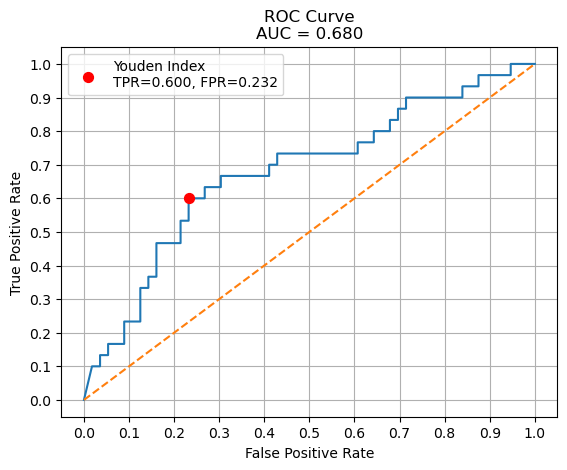

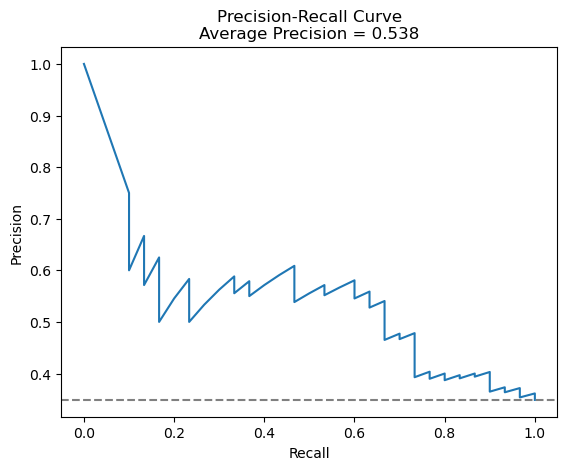

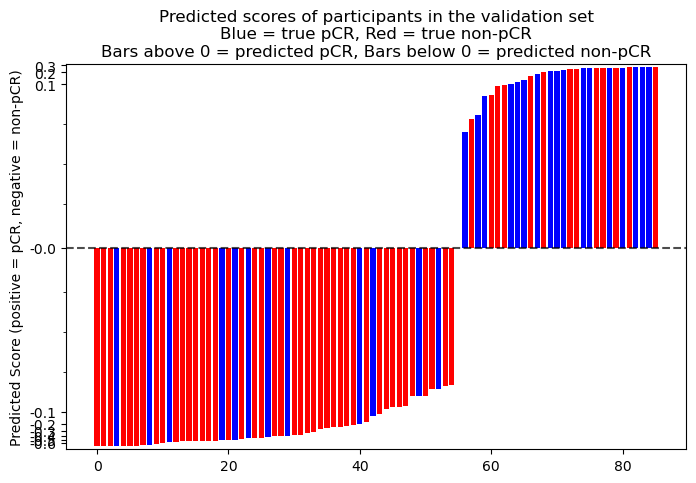

In [80]:
from models.CMC_Model.model import Model as CMCModel

model = CMCModel().to(device)

trainedModel = getTrainedModel(
    model,
    combine_timepoints=True,
    out_features=2,
    loss_fn=torch.nn.CrossEntropyLoss(),
    trainKwargs={"mode": "both"},
    testKwargs={"mode": "preNac"},
    save = True,
    filename = "CMCModel_weights.pt"
)

plot(trainedModel, test_loader, combine_timepoints=True, out_features = 2)